# Sound Classification - MLOps Summative

End-to-end notebook for a non-tabular (audio) classification pipeline on the
**ESC-10** subset of ESC-50 (10 environmental sound classes).

Sections:
1. Data acquisition
2. Exploratory data analysis (3 feature interpretations)
3. Preprocessing (wav to log-mel-spectrogram)
4. Model creation (optimized CNN)
5. Training (early stopping, regularization)
6. Evaluation (accuracy, loss, precision, recall, F1)
7. Prediction function
8. Export model

In [1]:
import json
import shutil
import zipfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

ROOT: Path = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_DIR: Path = ROOT / "data"
RAW_DIR: Path = DATA_DIR / "raw"
TRAIN_DIR: Path = DATA_DIR / "train"
TEST_DIR: Path = DATA_DIR / "test"
MODELS_DIR: Path = ROOT / "models"

SAMPLE_RATE: int = 22050
DURATION: float = 5.0
SAMPLES_PER_CLIP: int = int(SAMPLE_RATE * DURATION)
N_MELS: int = 128
N_FFT: int = 2048
HOP_LENGTH: int = 512

TRAINVAL_FOLDS: List[int] = [1, 2, 3, 4]
TEST_FOLD: int = 5
VAL_FRACTION: float = 0.15

np.random.seed(42)
tf.random.set_seed(42)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("TensorFlow", tf.__version__)
print("Root:", ROOT)

2026-07-23 01:32:25.764193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.16.2
Root: /Users/michael/Documents/school/alu-ml-ops-summative


## 1. Data acquisition

Download ESC-50, keep the 10-class ESC-10 subset, and lay the wav files out under `data/train` and `data/test` by fold.

In [2]:
ESC50_URL: str = "https://github.com/karoldvl/ESC-50/archive/master.zip"
RAW_DIR.mkdir(parents=True, exist_ok=True)
extracted: Path = RAW_DIR / "ESC-50-master"

if not extracted.exists():
    zip_path: Path = RAW_DIR / "esc50.zip"
    if not zip_path.exists():
        print("Downloading ESC-50 (about 600 MB) ...")
        urllib.request.urlretrieve(ESC50_URL, zip_path)
    print("Extracting ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(RAW_DIR)

audio_dir: Path = extracted / "audio"
meta: pd.DataFrame = pd.read_csv(extracted / "meta" / "esc50.csv")
esc10: pd.DataFrame = meta[meta["esc10"]].reset_index(drop=True)
class_names: List[str] = sorted(esc10["category"].unique().tolist())

print("ESC-10 classes:", class_names)
print("Total clips:", len(esc10))
esc10.head()

ESC-10 classes: ['chainsaw', 'clock_tick', 'crackling_fire', 'crying_baby', 'dog', 'helicopter', 'rain', 'rooster', 'sea_waves', 'sneezing']
Total clips: 400


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-110389-A-0.wav,1,0,dog,True,110389,A
2,1-116765-A-41.wav,1,41,chainsaw,True,116765,A
3,1-17150-A-12.wav,1,12,crackling_fire,True,17150,A
4,1-172649-A-40.wav,1,40,helicopter,True,172649,A


In [3]:
def populate_split_dirs() -> None:
    for split_dir in (TRAIN_DIR, TEST_DIR):
        if split_dir.exists():
            shutil.rmtree(split_dir)
        split_dir.mkdir(parents=True, exist_ok=True)
    for _, row in esc10.iterrows():
        split: Path = TEST_DIR if row["fold"] == TEST_FOLD else TRAIN_DIR
        dest: Path = split / row["category"]
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy(audio_dir / row["filename"], dest / row["filename"])

populate_split_dirs()
print("Copied wav files into data/train and data/test")

Copied wav files into data/train and data/test


## 2. Exploratory data analysis

We interpret three features of the dataset. First we build a small feature table
by loading every clip once and measuring loudness, brightness, and noisiness.

In [4]:
def clip_features(path: Path) -> Dict[str, float]:
    waveform, _ = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)
    rms: float = float(np.mean(librosa.feature.rms(y=waveform)))
    centroid: float = float(np.mean(librosa.feature.spectral_centroid(y=waveform, sr=SAMPLE_RATE)))
    zcr: float = float(np.mean(librosa.feature.zero_crossing_rate(y=waveform)))
    return {"rms": rms, "centroid": centroid, "zcr": zcr}

rows: List[Dict[str, float]] = []
for _, r in esc10.iterrows():
    feats: Dict[str, float] = clip_features(audio_dir / r["filename"])
    feats["category"] = r["category"]
    rows.append(feats)

feat_df: pd.DataFrame = pd.DataFrame(rows)
feat_df.head()

/Users/michael/.pyenv/versions/3.10.19/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,rms,centroid,zcr,category
0,0.008202,217.341851,0.013179,dog
1,0.006979,161.044643,0.006879,dog
2,0.160884,2292.949080,0.099609,chainsaw
3,0.023919,3090.588390,0.094679,crackling_fire
4,0.176530,4543.646258,0.322202,helicopter


### Feature 1: Class distribution

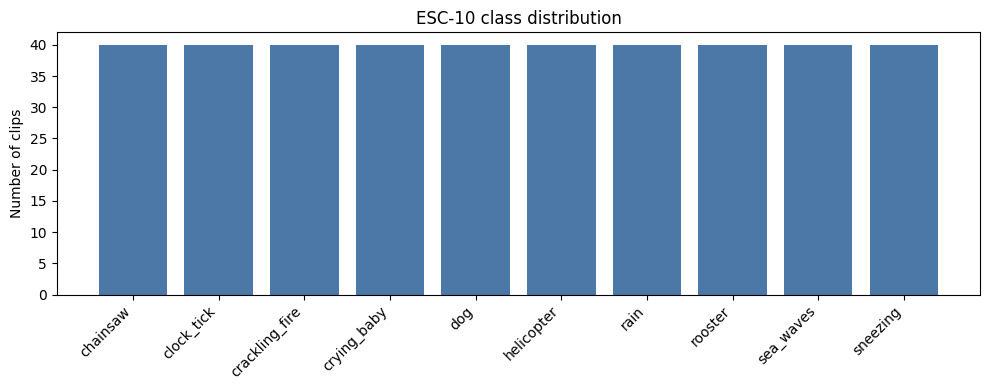

In [5]:
counts = feat_df["category"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
plt.bar(counts.index, counts.values, color="#4C78A8")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of clips")
plt.title("ESC-10 class distribution")
plt.tight_layout()
plt.show()

**Story:** Every class has exactly 40 clips. The dataset is perfectly balanced, so plain accuracy is a fair headline metric and no class weighting is needed.

### Feature 2: Loudness (RMS energy) by class

/var/folders/8p/b_cj65j96fz4h47rt8tp35080000gp/T/ipykernel_12086/866795528.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat_df[feat_df["category"] == c]["rms"] for c in order], labels=order)


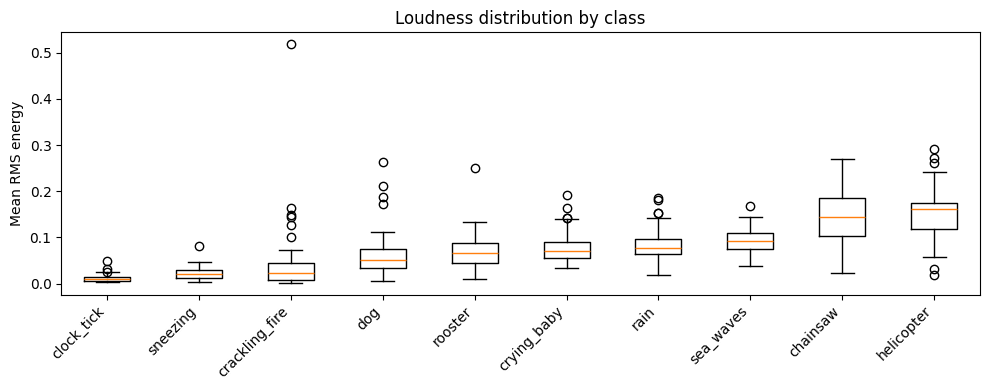

In [6]:
order = feat_df.groupby("category")["rms"].median().sort_values().index
plt.figure(figsize=(10, 4))
plt.boxplot([feat_df[feat_df["category"] == c]["rms"] for c in order], labels=order)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean RMS energy")
plt.title("Loudness distribution by class")
plt.tight_layout()
plt.show()

**Story:** Sustained sources like `helicopter` and `chainsaw` carry high, steady energy, while sparse transient sounds like `clock_tick` sit low. Loudness alone already separates several classes, which is why an energy-aware model does well here.

### Feature 3: Brightness (spectral centroid) by class

/var/folders/8p/b_cj65j96fz4h47rt8tp35080000gp/T/ipykernel_12086/1758681458.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat_df[feat_df["category"] == c]["centroid"] for c in order], labels=order)


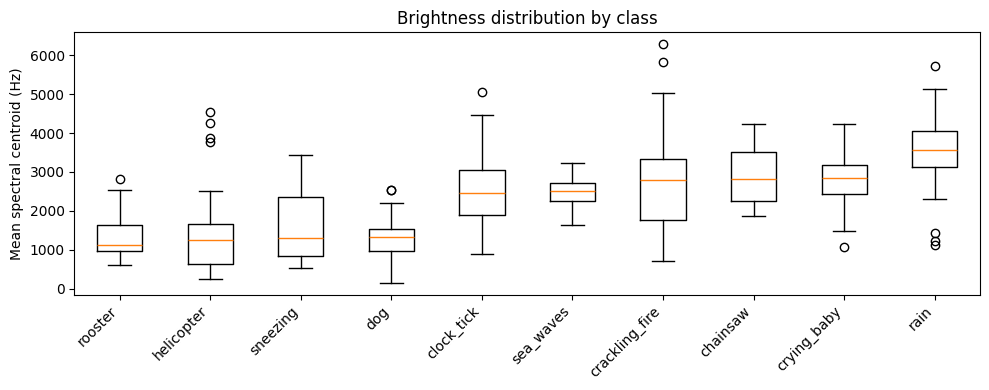

In [7]:
order = feat_df.groupby("category")["centroid"].median().sort_values().index
plt.figure(figsize=(10, 4))
plt.boxplot([feat_df[feat_df["category"] == c]["centroid"] for c in order], labels=order)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean spectral centroid (Hz)")
plt.title("Brightness distribution by class")
plt.tight_layout()
plt.show()

**Story:** Spectral centroid measures where the "center of mass" of the spectrum
sits. Bright, high-frequency sounds (`clock_tick`, `sneezing`) score high, while
low rumbling sounds (`sea_waves`, `helicopter`) score low. Brightness and
loudness together give the model complementary cues, which the mel-spectrogram
captures in full.

### Mel-spectrograms across classes

The CNN learns from these images. Tonal sounds show horizontal harmonic bands; broadband sounds look like textured noise.

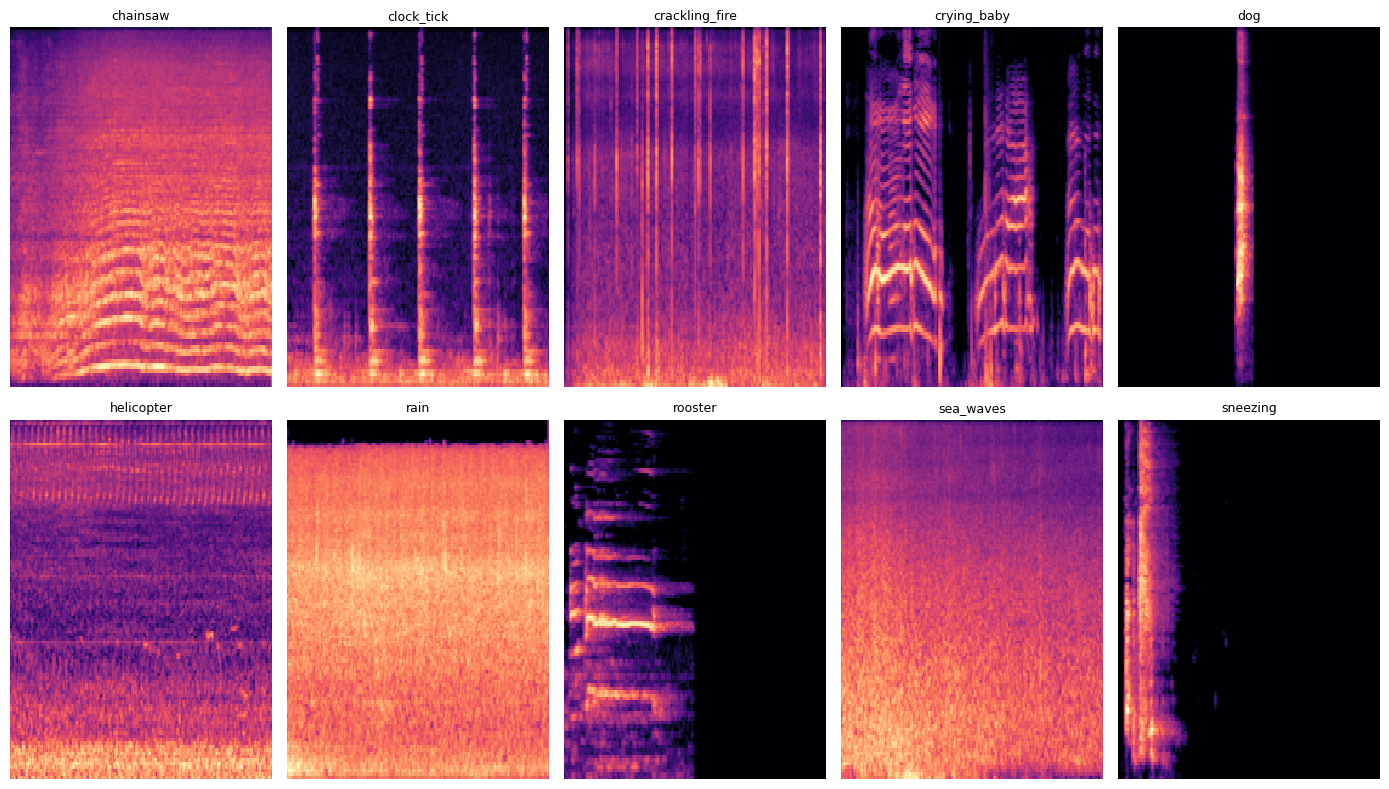

In [8]:
sample = esc10.groupby("category").first().reset_index()
plt.figure(figsize=(14, 8))
for i, row in sample.iterrows():
    waveform, _ = librosa.load(audio_dir / row["filename"], sr=SAMPLE_RATE, duration=DURATION)
    mel = librosa.feature.melspectrogram(y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    plt.subplot(2, 5, i + 1)
    librosa.display.specshow(log_mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
    plt.title(row["category"], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preprocessing

The functions below are the single source of truth for turning a wav file into a
model input. The API and the retraining pipeline reuse the exact same steps so
predictions stay consistent everywhere.

In [9]:
def load_audio(path: Path) -> np.ndarray:
    waveform, _ = librosa.load(path, sr=SAMPLE_RATE)
    if len(waveform) < SAMPLES_PER_CLIP:
        waveform = np.pad(waveform, (0, SAMPLES_PER_CLIP - len(waveform)))
    return waveform[:SAMPLES_PER_CLIP]


def to_melspectrogram(waveform: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    normalized = (log_mel + 80.0) / 80.0
    return np.clip(normalized, 0.0, 1.0).astype(np.float32)


def augment(waveform: np.ndarray) -> List[np.ndarray]:
    noisy = waveform + 0.005 * np.random.randn(len(waveform)).astype(np.float32)
    shifted = np.roll(waveform, int(SAMPLE_RATE * 0.2))
    pitched = librosa.effects.pitch_shift(waveform, sr=SAMPLE_RATE, n_steps=2)
    return [noisy, shifted, pitched.astype(np.float32)]

In [10]:
def build_dataset(df: pd.DataFrame, augment_data: bool) -> Tuple[np.ndarray, np.ndarray]:
    specs: List[np.ndarray] = []
    labels: List[int] = []
    for _, r in df.iterrows():
        waveform = load_audio(audio_dir / r["filename"])
        variants = [waveform] + (augment(waveform) if augment_data else [])
        for v in variants:
            specs.append(to_melspectrogram(v))
            labels.append(class_names.index(r["category"]))
    x = np.array(specs)[..., np.newaxis]
    y = np.array(labels)
    return x, y

# Fold 5 stays a clean held-out test. Train/val are a stratified split of folds
# 1 to 4 so validation tracks training and early stopping picks a real model.
trainval_df = esc10[esc10["fold"].isin(TRAINVAL_FOLDS)]
test_df = esc10[esc10["fold"] == TEST_FOLD]

train_df, val_df = train_test_split(
    trainval_df, test_size=VAL_FRACTION, stratify=trainval_df["category"], random_state=42
)

x_train, y_train = build_dataset(train_df, augment_data=True)
x_val, y_val = build_dataset(val_df, augment_data=False)
x_test, y_test = build_dataset(test_df, augment_data=False)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

Train: (1088, 128, 216, 1) Val: (48, 128, 216, 1) Test: (80, 128, 216, 1)


## 4. Model creation

A compact CNN with BatchNorm, L2 regularization, and dropout. Small enough for CPU training, regularized to avoid overfitting the small dataset.

In [11]:
def build_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    bn = lambda: layers.BatchNormalization(momentum=0.9)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        bn(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        bn(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        bn(),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

input_shape: Tuple[int, int, int] = x_train.shape[1:]
model = build_model(input_shape, len(class_names))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Training

Early stopping tracks validation accuracy and restores the best weights; ReduceLROnPlateau eases the learning rate when validation accuracy stalls.

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", mode="max", patience=6, factor=0.5, min_lr=1e-5),
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/80


34/34 - 47s - 1s/step - accuracy: 0.2803 - loss: 2.0049 - val_accuracy: 0.2708 - val_loss: 2.0807 - learning_rate: 5.0000e-04


Epoch 2/80


34/34 - 43s - 1s/step - accuracy: 0.4090 - loss: 1.6543 - val_accuracy: 0.5833 - val_loss: 1.2216 - learning_rate: 5.0000e-04


Epoch 3/80


...

34/34 - 50s - 1s/step - accuracy: 0.8805 - loss: 0.3996 - val_accuracy: 0.9167 - val_loss: 0.3621 - learning_rate: 1.5625e-05


Epoch 47/80


34/34 - 50s - 1s/step - accuracy: 0.8759 - loss: 0.4013 - val_accuracy: 0.9167 - val_loss: 0.3650 - learning_rate: 1.5625e-05


Epoch 48/80


34/34 - 44s - 1s/step - accuracy: 0.8722 - loss: 0.3884 - val_accuracy: 0.9167 - val_loss: 0.3607 - learning_rate: 1.5625e-05


## 6. Evaluation

Five metrics: accuracy, loss, precision, recall, and F1, plus a per-class report and confusion matrix.

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
y_prob = model.predict(x_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "loss": test_loss,
    "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

print()
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

accuracy  : 0.8625
loss      : 0.4430
precision : 0.8721
recall    : 0.8625
f1        : 0.8629

                precision    recall  f1-score   support

      chainsaw       1.00      0.88      0.93         8
    clock_tick       0.88      0.88      0.88         8
crackling_fire       1.00      0.88      0.93         8
   crying_baby       1.00      1.00      1.00         8
           dog       0.60      0.75      0.67         8
    helicopter       0.89      1.00      0.94         8
          rain       0.78      0.88      0.82         8
       rooster       0.89      1.00      0.94         8
     sea_waves       0.86      0.75      0.80         8
      sneezing       0.83      0.62      0.71         8

      accuracy                           0.86        80
     macro avg       0.87      0.86      0.86        80
  weighted avg       0.87      0.86      0.86        80



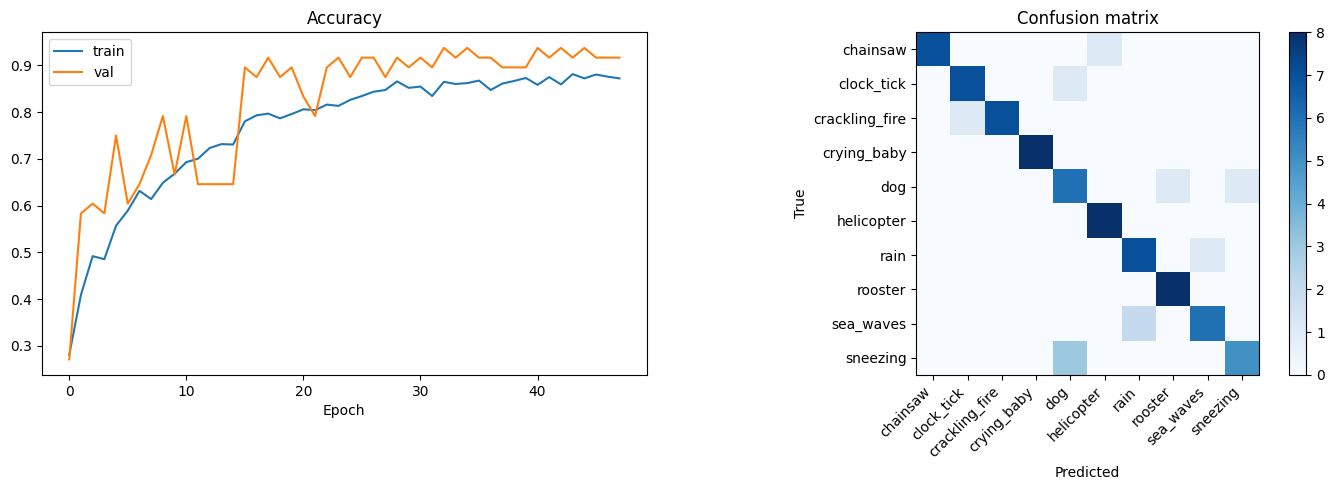

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(len(class_names)))
axes[1].set_yticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=45, ha="right")
axes[1].set_yticklabels(class_names)
axes[1].set_title("Confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Prediction function

Single wav in, predicted class and confidence out. This mirrors what the API serves.

In [15]:
def predict_wav(path: Path, trained_model: tf.keras.Model, labels: List[str]) -> Dict[str, float]:
    waveform = load_audio(Path(path))
    spec = to_melspectrogram(waveform)[np.newaxis, ..., np.newaxis]
    prob = trained_model.predict(spec, verbose=0)[0]
    idx = int(prob.argmax())
    return {"label": labels[idx], "confidence": float(prob[idx])}

sample_path = audio_dir / test_df.iloc[0]["filename"]
print("True label:", test_df.iloc[0]["category"])
print("Prediction:", predict_wav(sample_path, model, class_names))

True label: crying_baby
Prediction: {'label': 'crying_baby', 'confidence': 0.9101621508598328}


## 8. Export model

Save the trained model and the class names so the API and retraining can load them.

In [16]:
model_path = MODELS_DIR / "sound_model.h5"
model.save(model_path)
with open(MODELS_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f)
print("Saved model to", model_path)
print("Saved class names:", class_names)

Saved model to /Users/michael/Documents/school/alu-ml-ops-summative/models/sound_model.h5
Saved class names: ['chainsaw', 'clock_tick', 'crackling_fire', 'crying_baby', 'dog', 'helicopter', 'rain', 'rooster', 'sea_waves', 'sneezing']
